# Лабораторная работа 3: Обучение с учителем. Задача классификации

**Датасет:** `stud_end.csv`  
**Целевой признак:** `Target`  
**Модели:** Logistic Regression, kNN, пользовательский kNN, Naive Bayes, SVM  
**Оценка:** hold-out (`train/val/test`) + `StratifiedKFold(10)`  
**Пользовательские файлы:** `metrics_cls.py`, `custom_knn.py`

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)
from sklearn.utils import resample

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import metrics_cls as cm
from custom_knn import CustomKNNClassifier

## 1. Загрузка и подготовка данных

Загружаем датасет, выделяем предикторы и целевой признак, определяем тип задачи классификации и проверяем баланс классов.

In [48]:
data = pd.read_csv('stud_end.csv')

target = 'Target'
X = data.drop(columns=[target])
y = data[target]
classes = np.sort(y.unique())

problem_type = 'Бинарная' if y.nunique() == 2 else 'Мультиклассовая'
print(f'Тип задачи: {problem_type}')
print('Размер датасета:', data.shape)
print('Классы:', classes)
print()
print('Распределение классов:')
print(y.value_counts().sort_index())

Тип задачи: Мультиклассовая
Размер датасета: (3171, 97)
Классы: [0 1 2]

Распределение классов:
Target
0     571
1     654
2    1946
Name: count, dtype: int64


Отношение max/min: 3.41


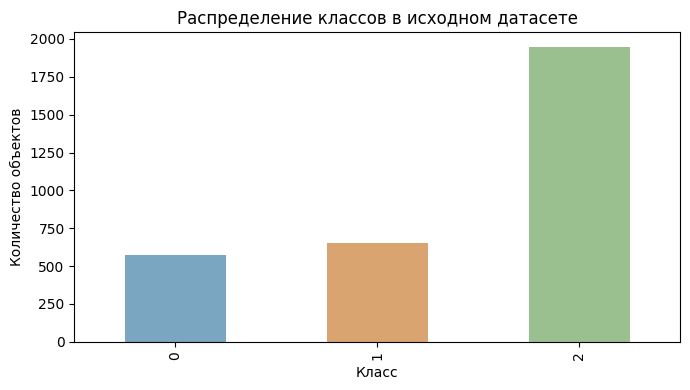

In [49]:
class_counts = y.value_counts().sort_index()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f'Отношение max/min: {imbalance_ratio:.2f}')

plt.figure(figsize=(7, 4))
class_counts.plot(kind='bar', color=['#7aa6c2', '#d9a46f', '#9ac08f'])
plt.title('Распределение классов в исходном датасете')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.tight_layout()
plt.show()

Для hold-out используем стратифицированное разбиение **60 / 20 / 20** (train / val / test).

Балансировка проводится **только на обучающей выборке** — валидационная и тестовая сохраняют реальное распределение классов.

Стратегия балансировки зависит от модели:

| Модель | Обучающие данные | Способ компенсации дисбаланса |
|--------|-----------------|-------------------------------|
| Logistic Regression, Naive Bayes | `X_train_bal` (oversampling) | Дублирование миноритарных классов |
| kNN (sklearn + custom) | `X_train_full` | — (oversampling создаёт дубликаты на расстоянии 0, что ломает метрику расстояния) |
| SVM | `X_train_full` | `class_weight='balanced'` — встроенный весовой механизм |


In [50]:
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print('Train:', X_train_full.shape, y_train_full.shape)
print('Val:  ', X_val.shape, y_val.shape)
print('Test: ', X_test.shape, y_test.shape)

Train: (1902, 96) (1902,)
Val:   (634, 96) (634,)
Test:  (635, 96) (635,)


In [51]:
def balance_train_oversample(X_train, y_train, random_state=42):
    train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
    max_size = train_df[target].value_counts().max()
    balanced_parts = []

    for _, group in train_df.groupby(target):
        balanced_group = resample(group, replace=True, n_samples=max_size, random_state=random_state)
        balanced_parts.append(balanced_group)

    balanced_df = pd.concat(balanced_parts, axis=0)
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    X_bal = balanced_df.drop(columns=[target])
    y_bal = balanced_df[target]
    return X_bal, y_bal

X_train_bal, y_train_bal = balance_train_oversample(X_train_full, y_train_full)

print('До балансировки:')
print(y_train_full.value_counts().sort_index())
print()
print('После балансировки:')
print(y_train_bal.value_counts().sort_index())

До балансировки:
Target
0     343
1     392
2    1167
Name: count, dtype: int64

После балансировки:
Target
0    1167
1    1167
2    1167
Name: count, dtype: int64


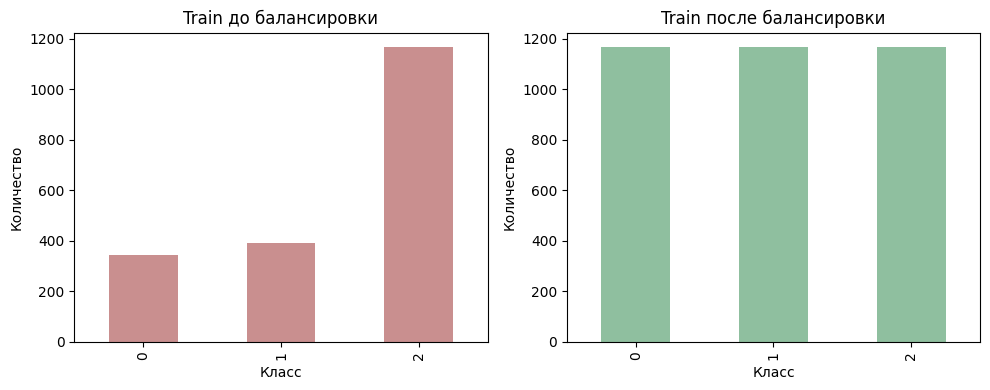

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train_full.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#c98f8f')
axes[0].set_title('Train до балансировки')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество')

y_train_bal.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#8fbf9f')
axes[1].set_title('Train после балансировки')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Количество')
plt.tight_layout()
plt.show()

## 2. Вспомогательные функции

Ниже определены функции для обучения моделей, подбора гиперпараметров, вычисления метрик, hold-out оценки и 10-fold кросс-валидации.

In [53]:
SEARCH_CV = 3
KFOLD_SPLITS = 10
SCORING = 'f1_macro'
RANDOM_STATE = 42


# Экспоненциальное ядро для SVM: строит матрицу попарных сходств.
def exponential_kernel(gamma=0.1):
    def kernel(X1, X2):
        X1_sq = np.sum(X1 ** 2, axis=1)[:, None]
        X2_sq = np.sum(X2 ** 2, axis=1)[None, :]
        distances = np.sqrt(np.maximum(X1_sq + X2_sq - 2 * X1 @ X2.T, 0.0))
        return np.exp(-gamma * distances)
    return kernel


# Собирает pipeline модели; масштабирование включаем для методов, чувствительных к масштабу.
def make_pipeline(model, scale=True):
    if scale:
        return Pipeline([('scaler', StandardScaler()), ('model', model)])
    return Pipeline([('model', model)])


# Считает основные метрики классификации из sklearn с macro-усреднением.
def sklearn_metrics(y_true, y_pred):
    return {
        'F1': round(f1_score(y_true, y_pred, average='macro'), 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
    }


# Сравнивает sklearn-метрики с пользовательской реализацией из metrics_cls.py.
def compare_metrics(y_true, y_pred):
    sk = sklearn_metrics(y_true, y_pred)
    custom = cm.all_metrics(y_true, y_pred, labels=classes)
    row = {}
    for key, value in sk.items():
        row[f'sk {key}'] = value
    for key, value in custom.items():
        row[f'my {key}'] = value
    return row


# Обучает модель и сразу возвращает предсказания и метрики на train/test.
def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)
    train_metrics = sklearn_metrics(y_tr, train_pred)
    test_metrics = sklearn_metrics(y_te, test_pred)
    return model, train_pred, test_pred, train_metrics, test_metrics


# Выбирает лучший вариант модели по качеству на validation-выборке.
def choose_best_by_validation(candidates, X_tr, y_tr, X_val_local, y_val_local):
    fitted = {}
    scores = {}
    for name, estimator in candidates.items():
        estimator.fit(X_tr, y_tr)
        val_pred = estimator.predict(X_val_local)
        fitted[name] = estimator
        scores[name] = f1_score(y_val_local, val_pred, average='macro')
    best_name = max(scores, key=scores.get)
    return fitted[best_name], best_name, scores


# Запускает три способа подбора гиперпараметров: GridSearchCV, RandomizedSearchCV и Optuna.
def run_searches(base_pipeline, param_grid, param_distributions, optuna_builder, X_search, y_search, n_trials=10):
    grid = GridSearchCV(base_pipeline, param_grid, cv=SEARCH_CV, scoring=SCORING, n_jobs=1)
    grid.fit(X_search, y_search)

    rnd = RandomizedSearchCV(
        base_pipeline,
        param_distributions=param_distributions,
        n_iter=min(8, np.prod([len(v) for v in param_distributions.values()])),
        cv=SEARCH_CV,
        scoring=SCORING,
        n_jobs=1,
        random_state=RANDOM_STATE,
    )
    rnd.fit(X_search, y_search)

    # Optuna оптимизирует качество модели на validation-выборке.
    def objective(trial):
        model = optuna_builder(trial)
        model.fit(X_search, y_search)
        pred = model.predict(X_val)
        return f1_score(y_val, pred, average='macro')

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    opt_model = optuna_builder(study.best_trial)
    opt_model.fit(X_search, y_search)

    return {
        'GridSearchCV': grid.best_estimator_,
        'RandomizedSearchCV': rnd.best_estimator_,
        'Optuna': opt_model,
    }


# Считает метрики на 10 стратифицированных фолдах и сводит их в таблицу.
def cross_val_metrics(estimator_factory, X_data, y_data, balance_train=True):
    skf = StratifiedKFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    rows = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_data, y_data), start=1):
        X_tr = X_data.iloc[train_idx].reset_index(drop=True)
        y_tr = y_data.iloc[train_idx].reset_index(drop=True)
        X_te = X_data.iloc[test_idx].reset_index(drop=True)
        y_te = y_data.iloc[test_idx].reset_index(drop=True)

        # Балансировку проводим только внутри обучающей части каждого фолда.
        if balance_train:
            X_tr, y_tr = balance_train_oversample(X_tr, y_tr, random_state=RANDOM_STATE + fold)

        estimator = estimator_factory()
        estimator.fit(X_tr, y_tr)
        pred = estimator.predict(X_te)
        metrics = sklearn_metrics(y_te, pred)
        metrics['Fold'] = fold
        rows.append(metrics)

    fold_df = pd.DataFrame(rows)
    summary = {
        metric: f"{fold_df[metric].mean():.4f} ± {fold_df[metric].std():.4f}"
        for metric in ['F1', 'Accuracy', 'Precision', 'Recall']
    }
    return fold_df, summary


# Формирует одну строку итоговой hold-out таблицы по модели.
def holdout_row(name, train_metrics, test_metrics):
    return {
        'Классификатор': name,
        **{f'Train {k}': v for k, v in train_metrics.items()},
        **{f'Test {k}': v for k, v in test_metrics.items()},
    }


# Строит confusion matrix для выбранной модели на тестовой выборке.
def add_confusion_plot(model, X_te, y_te, title):
    pred = model.predict(X_te)
    cmatrix = confusion_matrix(y_te, pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cmatrix, display_labels=classes)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.grid(False)
    plt.show()

## 3. Решение задачи классификации

Задача является **мультиклассовой**, поэтому для основных метрик используем `macro`-усреднение. Это даёт более честную оценку качества на несбалансированных классах.

### 3.1. Logistic Regression

Особенности модели:
- линейный классификатор, хорошо интерпретируется;
- является сильным базовым методом для задач классификации;
- чувствительна к масштабу признаков, поэтому используется `StandardScaler`.

**Балансировка:** обучается на `X_train_bal` (oversampling). Для логистической регрессии oversampling безопасен — модель не запоминает отдельные точки, а обновляет веса по всей выборке.  
Гиперпараметр `class_weight` также включён в сетку поиска как альтернатива.


In [54]:
# LogReg обучается на сбалансированной выборке.
log_reg_pipe = make_pipeline(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
)

log_reg_candidates = run_searches(
    base_pipeline=log_reg_pipe,
    param_grid={
        'model__C': [0.03, 0.1, 0.3, 1.0, 3.0],
        'model__class_weight': [None, 'balanced'],
    },
    param_distributions={
        'model__C': [0.03, 0.05, 0.1, 0.3, 1.0, 3.0, 10.0],
        'model__class_weight': [None, 'balanced'],
    },
    optuna_builder=lambda trial: make_pipeline(
        LogisticRegression(
            C=trial.suggest_float('C', 0.03, 10.0, log=True),
            class_weight=trial.suggest_categorical('class_weight', [None, 'balanced']),
            max_iter=5000,
            random_state=RANDOM_STATE,
        )
    ),
    X_search=X_train_bal,
    y_search=y_train_bal,
    n_trials=12,
)

model_log_reg, log_reg_method, log_reg_scores = choose_best_by_validation(
    log_reg_candidates, X_train_bal, y_train_bal, X_val, y_val
)

model_log_reg, y_log_train, y_log_test, log_train_metrics, log_test_metrics = evaluate_model(
    model_log_reg, X_train_bal, y_train_bal, X_test, y_test
)

print('Validation scores:', log_reg_scores)
print('Лучший способ подбора:', log_reg_method)


Validation scores: {'GridSearchCV': 0.6220226594513952, 'RandomizedSearchCV': 0.620753538150345, 'Optuna': 0.623123782072468}
Лучший способ подбора: Optuna


### 3.2. kNN из Scikit-learn

Особенности модели:
- классификация происходит по ближайшим соседям в пространстве признаков;
- качество зависит от `k`, метрики расстояния и масштаба признаков;
- чувствительна к шуму и размерности пространства.

**Балансировка:** обучается на `X_train_full` (без oversampling).  
Причина: oversampling создаёт точные дубликаты. При поиске соседей kNN находит дубликат на расстоянии 0, что искусственно завышает Train метрики до 1.0 и не отражает реальное качество модели.  
Исследуем метрики расстояния (Euclidean, Manhattan) и их влияние на качество.


In [55]:
# kNN чувствителен к дубликатам из oversampling — используем исходный train.
k_values = list(range(3, 22, 2))
knn_curve_rows = []
for k in k_values:
    candidate = make_pipeline(KNeighborsClassifier(n_neighbors=k, metric='manhattan', weights='uniform'))
    candidate.fit(X_train_full, y_train_full)
    pred_val = candidate.predict(X_val)
    knn_curve_rows.append({
        'k': k,
        'Accuracy': accuracy_score(y_val, pred_val),
        'F1': f1_score(y_val, pred_val, average='macro'),
    })

df_knn_curve = pd.DataFrame(knn_curve_rows)
df_knn_curve


,k,Accuracy,F1
0,3,0.638801,0.474160
1,5,0.676656,0.514919
2,7,0.667192,0.480927
3,9,0.652997,0.448452
4,11,0.660883,0.459761
5,13,0.660883,0.450442
6,15,0.664038,0.456038
7,17,0.671924,0.464843
8,19,0.671924,0.456647
9,21,0.665615,0.446107


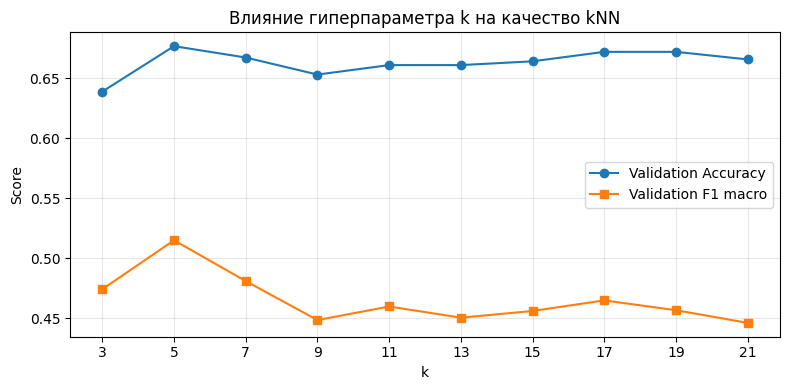

In [56]:
plt.figure(figsize=(8, 4))
plt.plot(df_knn_curve['k'], df_knn_curve['Accuracy'], marker='o', label='Validation Accuracy')
plt.plot(df_knn_curve['k'], df_knn_curve['F1'], marker='s', label='Validation F1 macro')
plt.xlabel('k')
plt.ylabel('Score')
plt.title('Влияние гиперпараметра k на качество kNN')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
knn_pipe = make_pipeline(KNeighborsClassifier())

knn_candidates = run_searches(
    base_pipeline=knn_pipe,
    param_grid={
        'model__n_neighbors': [5, 7, 9, 11, 13, 15],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan'],
    },
    param_distributions={
        'model__n_neighbors': [5, 7, 9, 11, 13, 15, 17, 19],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan'],
    },
    optuna_builder=lambda trial: make_pipeline(
        KNeighborsClassifier(
            n_neighbors=trial.suggest_int('n_neighbors', 5, 19, step=2),
            weights=trial.suggest_categorical('weights', ['uniform', 'distance']),
            metric=trial.suggest_categorical('metric', ['euclidean', 'manhattan']),
        )
    ),
    X_search=X_train_full,
    y_search=y_train_full,
    n_trials=10,
)

model_knn, knn_method, knn_scores = choose_best_by_validation(
    knn_candidates, X_train_full, y_train_full, X_val, y_val
)

model_knn, y_knn_train, y_knn_test, knn_train_metrics, knn_test_metrics = evaluate_model(
    model_knn, X_train_full, y_train_full, X_test, y_test
)

print('Validation scores:', knn_scores)
print('Лучший способ подбора:', knn_method)


Validation scores: {'GridSearchCV': 0.5149193929269232, 'RandomizedSearchCV': 0.5100193726870833, 'Optuna': 0.5149193929269232}
Лучший способ подбора: GridSearchCV


### 3.3. Пользовательский kNN

Особенности модели:
- полностью реализован вручную в файле `custom_knn.py`;
- поддерживает выбор `k` и метрики расстояния (Euclidean, Manhattan);
- позволяет сравнить собственную реализацию с эталонным `sklearn`-классификатором.

**Балансировка:** аналогично sklearn kNN — используется `X_train_full`.  
Конфигурация (`k=9`, `metric='manhattan'`) подобрана по валидационной кривой из предыдущего шага.


In [58]:
# Custom kNN — конфигурация подобрана по кривой выше; X_train_full как и sklearn kNN.
custom_knn = make_pipeline(CustomKNNClassifier(n_neighbors=9, metric='manhattan'))
custom_knn.fit(X_train_full, y_train_full)
custom_knn_train_pred = custom_knn.predict(X_train_full)
custom_knn_test_pred  = custom_knn.predict(X_test)
custom_knn_train_metrics = sklearn_metrics(y_train_full, custom_knn_train_pred)
custom_knn_test_metrics  = sklearn_metrics(y_test, custom_knn_test_pred)


### 3.4. Naive Bayes

Особенности модели:
- основана на предположении условной независимости признаков;
- обучается очень быстро и часто хорошо работает как простой базовый классификатор;
- может уступать более гибким моделям при сложных зависимостях между признаками.

**Балансировка:** обучается на `X_train_bal` (oversampling).  
Для Naive Bayes oversampling безопасен — модель оценивает вероятности по частотам, дубликаты корректно сдвигают априорные вероятности в сторону балансировки.


In [59]:
# Naive Bayes обучается на сбалансированной выборке.
nb_pipe = make_pipeline(GaussianNB(), scale=False)

nb_candidates = run_searches(
    base_pipeline=nb_pipe,
    param_grid={
        'model__var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6],
    },
    param_distributions={
        'model__var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6],
    },
    optuna_builder=lambda trial: make_pipeline(
        GaussianNB(var_smoothing=trial.suggest_float('var_smoothing', 1e-10, 1e-5, log=True)),
        scale=False,
    ),
    X_search=X_train_bal,
    y_search=y_train_bal,
    n_trials=8,
)

model_nb, nb_method, nb_scores = choose_best_by_validation(
    nb_candidates, X_train_bal, y_train_bal, X_val, y_val
)

model_nb, y_nb_train, y_nb_test, nb_train_metrics, nb_test_metrics = evaluate_model(
    model_nb, X_train_bal, y_train_bal, X_test, y_test
)

print('Validation scores:', nb_scores)
print('Лучший способ подбора:', nb_method)


Validation scores: {'GridSearchCV': 0.4947043451239623, 'RandomizedSearchCV': 0.4947043451239623, 'Optuna': 0.500721277058141}
Лучший способ подбора: Optuna


### 3.5. SVM с различными ядрами

Особенности модели:
- строит оптимальную разделяющую гиперплоскость с максимальным отступом;
- с помощью ядерных функций работает в нелинейных пространствах признаков;
- чувствительна к масштабу — используется `StandardScaler`.

Исследуем ядра: `linear`, `poly`, `rbf`, `sigmoid` и `exponential` (пользовательское).  
Итоговой моделью считается ядро с наилучшим `F1 macro` на валидации.

**Балансировка:** используется `X_train_full` + параметр `class_weight='balanced'`.  
Это взвешивает штраф за ошибки на миноритарных классах без создания дубликатов.  
Для стандартных sklearn-ядер дополнительно запускается `run_searches` (Grid / Randomized / Optuna).

> **Замечание:** SVM с ядерными функциями склонен к переобучению на этом датасете —  
> Train F1 значительно выше Test F1. Это ожидаемое поведение для гибких ядер (RBF, Exponential)  
> при относительно небольшом числе обучающих примеров.


In [60]:
# SVM — используем X_train_full с class_weight='balanced' вместо oversampling.
# Oversampling создаёт дубликаты, которые RBF-ядро легко запоминает → переобучение.
svm_kernel_candidates = {
    'Linear Kernel':     make_pipeline(SVC(kernel='linear',  C=0.3, class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    'Polynomial Kernel': make_pipeline(SVC(kernel='poly',    C=1.0, degree=2, gamma='scale', class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    'RBF Kernel':        make_pipeline(SVC(kernel='rbf',     C=1.0, gamma='scale', class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    'Sigmoid Kernel':    make_pipeline(SVC(kernel='sigmoid', C=1.0, gamma=0.03,   class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
}

svm_kernel_scores = {}
for kernel_name, estimator in svm_kernel_candidates.items():
    estimator.fit(X_train_full, y_train_full)
    svm_kernel_scores[kernel_name] = f1_score(y_val, estimator.predict(X_val), average='macro')

exp_candidates = []
for C in [0.1, 0.3, 1.0]:
    for gamma in [0.01, 0.03, 0.1]:
        exp_model = make_pipeline(SVC(kernel=exponential_kernel(gamma), C=C, class_weight='balanced', probability=True, random_state=RANDOM_STATE))
        exp_model.fit(X_train_full, y_train_full)
        exp_score = f1_score(y_val, exp_model.predict(X_val), average='macro')
        exp_candidates.append((exp_score, C, gamma, exp_model))

best_exp_score, best_exp_C, best_exp_gamma, best_exp_model = max(exp_candidates, key=lambda x: x[0])
svm_kernel_scores['Exponential Kernel'] = best_exp_score

best_svm_kernel = max(svm_kernel_scores, key=svm_kernel_scores.get)
print('Лучшее ядро:', best_svm_kernel)

_svm_search_configs = {
    'Linear Kernel': (
        {'model__C': [0.03, 0.1, 0.3, 1.0, 3.0]},
        {'model__C': [0.03, 0.1, 0.3, 1.0, 3.0, 10.0]},
        lambda trial: make_pipeline(SVC(kernel='linear',
            C=trial.suggest_float('C', 0.01, 5.0, log=True),
            class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    ),
    'RBF Kernel': (
        {'model__C': [0.3, 1.0, 3.0], 'model__gamma': ['scale', 0.01, 0.1]},
        {'model__C': [0.1, 0.3, 1.0, 3.0], 'model__gamma': ['scale', 0.01, 0.05, 0.1]},
        lambda trial: make_pipeline(SVC(kernel='rbf',
            C=trial.suggest_float('C', 0.1, 5.0, log=True),
            gamma=trial.suggest_categorical('gamma', ['scale', 0.01, 0.05, 0.1]),
            class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    ),
    'Polynomial Kernel': (
        {'model__C': [0.3, 1.0, 3.0], 'model__degree': [2, 3]},
        {'model__C': [0.3, 1.0, 3.0], 'model__degree': [2, 3]},
        lambda trial: make_pipeline(SVC(kernel='poly',
            C=trial.suggest_float('C', 0.1, 5.0, log=True),
            degree=trial.suggest_int('degree', 2, 3),
            class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    ),
    'Sigmoid Kernel': (
        {'model__C': [0.3, 1.0, 3.0], 'model__gamma': [0.01, 0.03, 0.1]},
        {'model__C': [0.3, 1.0, 3.0], 'model__gamma': [0.01, 0.03, 0.1]},
        lambda trial: make_pipeline(SVC(kernel='sigmoid',
            C=trial.suggest_float('C', 0.1, 5.0, log=True),
            gamma=trial.suggest_float('gamma', 0.01, 0.1, log=True),
            class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    ),
}

if best_svm_kernel in _svm_search_configs:
    pg, pd_, ob = _svm_search_configs[best_svm_kernel]
    base_kernel = best_svm_kernel.split()[0].lower()
    svm_candidates_tuned = run_searches(
        base_pipeline=make_pipeline(SVC(kernel=base_kernel, class_weight='balanced',
                                         probability=True, random_state=RANDOM_STATE)),
        param_grid=pg,
        param_distributions=pd_,
        optuna_builder=ob,
        X_search=X_train_full,
        y_search=y_train_full,
        n_trials=10,
    )
    model_svm, svm_tune_method, svm_tune_scores = choose_best_by_validation(
        svm_candidates_tuned, X_train_full, y_train_full, X_val, y_val
    )
    print('Метод подбора SVM:', svm_tune_method, '| scores:', svm_tune_scores)
else:
    model_svm = best_exp_model

model_svm, y_svm_train, y_svm_test, svm_train_metrics, svm_test_metrics = evaluate_model(
    model_svm, X_train_full, y_train_full, X_test, y_test
)

pd.DataFrame({
    'Kernel': list(svm_kernel_scores.keys()),
    'Validation F1 macro': list(svm_kernel_scores.values()),
}).sort_values('Validation F1 macro', ascending=False)


Лучшее ядро: Exponential Kernel


,Kernel,Validation F1 macro
4,Exponential Kernel,0.640164
2,RBF Kernel,0.635949
0,Linear Kernel,0.614327
1,Polynomial Kernel,0.571406
3,Sigmoid Kernel,0.510777


## 4. Таблица сравнения kNN из sklearn и пользовательского kNN

In [61]:
df_knn_compare = pd.DataFrame([
    holdout_row('kNN from sklearn', knn_train_metrics, knn_test_metrics),
    holdout_row('Custom kNN', custom_knn_train_metrics, custom_knn_test_metrics),
]).set_index('Классификатор')
df_knn_compare

,Train F1,Train Accuracy,Train Precision,Train Recall,Test F1,Test Accuracy,Test Precision,Test Recall
Классификатор,,,,,,,,
kNN from sklearn,0.6719,0.7660,0.7331,0.6406,0.4955,0.6520,0.5378,0.4839
Custom kNN,0.5975,0.7292,0.7171,0.5621,0.5166,0.6772,0.5897,0.4987


## 5. Таблица hold-out результатов (Train/Test)

В таблице собраны метрики всех классификаторов на обучающей и тестовой выборках.

Большой разрыв между Train и Test F1 указывает на переобучение модели.  
Близкие значения говорят о хорошем обобщении.


In [62]:
holdout_rows = [
    holdout_row('Logistic Regression', log_train_metrics, log_test_metrics),
    holdout_row('kNN', knn_train_metrics, knn_test_metrics),
    holdout_row('Custom kNN', custom_knn_train_metrics, custom_knn_test_metrics),
    holdout_row('Naive Bayes', nb_train_metrics, nb_test_metrics),
    holdout_row(f'SVM ({best_svm_kernel})', svm_train_metrics, svm_test_metrics),
]

df_holdout = pd.DataFrame(holdout_rows).set_index('Классификатор')
df_holdout

,Train F1,Train Accuracy,Train Precision,Train Recall,Test F1,Test Accuracy,Test Precision,Test Recall
Классификатор,,,,,,,,
Logistic Regression,0.7361,0.7375,0.7376,0.7375,0.6310,0.7008,0.6239,0.6448
kNN,0.6719,0.7660,0.7331,0.6406,0.4955,0.6520,0.5378,0.4839
Custom kNN,0.5975,0.7292,0.7171,0.5621,0.5166,0.6772,0.5897,0.4987
Naive Bayes,0.5946,0.5950,0.6022,0.5950,0.5259,0.5890,0.5338,0.5461
SVM (Exponential Kernel),0.9331,0.9395,0.9255,0.9417,0.6096,0.7071,0.6166,0.6067


## 6. Таблица сравнения sklearn и пользовательских метрик

Проверяем, что пользовательские метрики из `metrics_cls.py` совпадают со значениями `scikit-learn`.

In [63]:
metrics_compare_rows = [
    {'Классификатор': 'Logistic Regression', **compare_metrics(y_test, y_log_test)},
    {'Классификатор': 'kNN', **compare_metrics(y_test, y_knn_test)},
    {'Классификатор': 'Custom kNN', **compare_metrics(y_test, custom_knn_test_pred)},
    {'Классификатор': 'Naive Bayes', **compare_metrics(y_test, y_nb_test)},
    {'Классификатор': f'SVM ({best_svm_kernel})', **compare_metrics(y_test, y_svm_test)},
]

df_metrics_compare = pd.DataFrame(metrics_compare_rows).set_index('Классификатор')
df_metrics_compare

,sk F1,sk Accuracy,sk Precision,sk Recall,my Accuracy,my Precision,my Recall,my F1
Классификатор,,,,,,,,
Logistic Regression,0.6310,0.7008,0.6239,0.6448,0.7008,0.6239,0.6448,0.6310
kNN,0.4955,0.6520,0.5378,0.4839,0.6520,0.5378,0.4839,0.4955
Custom kNN,0.5166,0.6772,0.5897,0.4987,0.6772,0.5897,0.4987,0.5166
Naive Bayes,0.5259,0.5890,0.5338,0.5461,0.5890,0.5338,0.5461,0.5259
SVM (Exponential Kernel),0.6096,0.7071,0.6166,0.6067,0.7071,0.6166,0.6067,0.6096


## 7. 10-fold кросс-валидация

Для каждого классификатора рассчитываем метрики на 10 стратифицированных фолдах.

Балансировка в CV воспроизводит условия hold-out:
- **Logistic Regression, Naive Bayes** — oversampling внутри каждого фолда (как в hold-out).
- **kNN, Custom kNN, SVM** — без балансировки (kNN чувствителен к дубликатам; SVM использует `class_weight='balanced'`).


In [64]:
cv_results = {}
cv_folds = {}

factories = {
    'Logistic Regression': (lambda: clone(model_log_reg), True),
    'kNN': (lambda: clone(model_knn), False),  # kNN — без балансировки (дубликаты ломают метрику)
    'Custom kNN': (lambda: make_pipeline(CustomKNNClassifier(n_neighbors=9, metric='manhattan')), False),
    'Naive Bayes': (lambda: clone(model_nb), True),
    f'SVM ({best_svm_kernel})': (lambda: clone(model_svm), False),
}

for name, (factory, use_balance) in factories.items():
    fold_df, summary = cross_val_metrics(factory, X, y, balance_train=use_balance)
    cv_folds[name] = fold_df
    cv_results[name] = summary

df_cv_summary = pd.DataFrame(cv_results).T
df_cv_summary.index.name = 'Классификатор'
df_cv_summary

,F1,Accuracy,Precision,Recall
Классификатор,,,,
Logistic Regression,0.6321 ± 0.0317,0.7029 ± 0.0247,0.6268 ± 0.0302,0.6462 ± 0.0356
kNN,0.5263 ± 0.0238,0.6767 ± 0.0210,0.5788 ± 0.0284,0.5112 ± 0.0222
Custom kNN,0.5021 ± 0.0406,0.6780 ± 0.0244,0.6050 ± 0.0468,0.4862 ± 0.0335
Naive Bayes,0.5142 ± 0.0300,0.5793 ± 0.0302,0.5232 ± 0.0225,0.5333 ± 0.0324
SVM (Exponential Kernel),0.6459 ± 0.0259,0.7275 ± 0.0221,0.6538 ± 0.0272,0.6447 ± 0.0289


In [65]:
best_holdout_name = df_holdout['Test F1'].idxmax()
cv_folds[best_holdout_name]

,F1,Accuracy,Precision,Recall,Fold
0,0.6218,0.7013,0.6260,0.6223,1
1,0.5937,0.6656,0.5912,0.6032,2
2,0.6733,0.7413,0.6708,0.6826,3
3,0.6477,0.7129,0.6414,0.6631,4
4,0.6758,0.7350,0.6614,0.7042,5
5,0.5973,0.6814,0.5897,0.6118,6
6,0.6663,0.7224,0.6550,0.6858,7
7,0.6012,0.6814,0.5941,0.6131,8
8,0.6152,0.6972,0.6088,0.6344,9
9,0.6288,0.6909,0.6293,0.6417,10


## 8. Таблица hold-out vs k-fold

Сравниваем качество моделей на тестовой выборке hold-out и средние значения метрик по 10 фолдам.

In [66]:
table3_rows = []
for name in df_cv_summary.index:
    table3_rows.append({
        'Классификатор': name,
        'Hold-out F1': df_holdout.loc[name, 'Test F1'],
        'Hold-out Accuracy': df_holdout.loc[name, 'Test Accuracy'],
        'Hold-out Precision': df_holdout.loc[name, 'Test Precision'],
        'Hold-out Recall': df_holdout.loc[name, 'Test Recall'],
        'k-fold F1': df_cv_summary.loc[name, 'F1'],
        'k-fold Accuracy': df_cv_summary.loc[name, 'Accuracy'],
        'k-fold Precision': df_cv_summary.loc[name, 'Precision'],
        'k-fold Recall': df_cv_summary.loc[name, 'Recall'],
    })

df_holdout_vs_cv = pd.DataFrame(table3_rows).set_index('Классификатор')
df_holdout_vs_cv

,Hold-out F1,Hold-out Accuracy,Hold-out Precision,Hold-out Recall,k-fold F1,k-fold Accuracy,k-fold Precision,k-fold Recall
Классификатор,,,,,,,,
Logistic Regression,0.6310,0.7008,0.6239,0.6448,0.6321 ± 0.0317,0.7029 ± 0.0247,0.6268 ± 0.0302,0.6462 ± 0.0356
kNN,0.4955,0.6520,0.5378,0.4839,0.5263 ± 0.0238,0.6767 ± 0.0210,0.5788 ± 0.0284,0.5112 ± 0.0222
Custom kNN,0.5166,0.6772,0.5897,0.4987,0.5021 ± 0.0406,0.6780 ± 0.0244,0.6050 ± 0.0468,0.4862 ± 0.0335
Naive Bayes,0.5259,0.5890,0.5338,0.5461,0.5142 ± 0.0300,0.5793 ± 0.0302,0.5232 ± 0.0225,0.5333 ± 0.0324
SVM (Exponential Kernel),0.6096,0.7071,0.6166,0.6067,0.6459 ± 0.0259,0.7275 ± 0.0221,0.6538 ± 0.0272,0.6447 ± 0.0289


## 9. Визуализация ошибок и ROC AUC

Покажем матрицу ошибок для лучшей модели по hold-out и построим ROC-кривые в схеме One-vs-Rest для многоклассовой задачи.

Лучшая hold-out модель: Logistic Regression


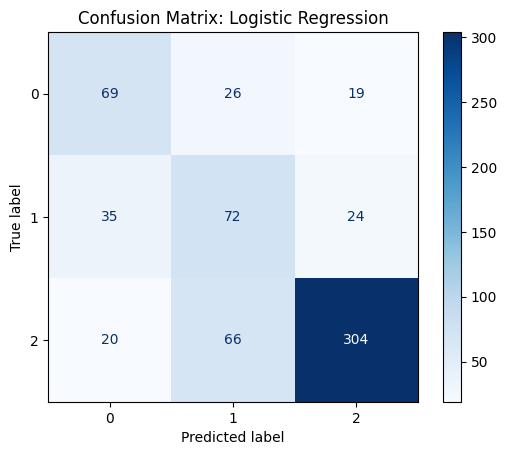

In [67]:
best_model_name = df_holdout['Test F1'].idxmax()
model_lookup = {
    'Logistic Regression': model_log_reg,
    'kNN': model_knn,
    'Custom kNN': custom_knn,
    'Naive Bayes': model_nb,
    f'SVM ({best_svm_kernel})': model_svm,
}

best_model = model_lookup[best_model_name]
print('Лучшая hold-out модель:', best_model_name)
add_confusion_plot(best_model, X_test, y_test, f'Confusion Matrix: {best_model_name}')

ROC AUC macro (OvR): 0.8219


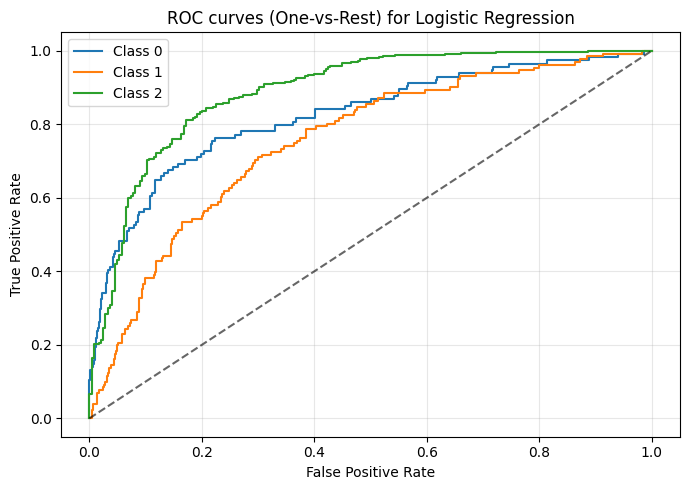

In [68]:
y_test_bin = label_binarize(y_test, classes=classes)

if hasattr(best_model, 'predict_proba'):
    y_score = best_model.predict_proba(X_test)
else:
    y_score = best_model.decision_function(X_test)

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
print(f'ROC AUC macro (OvR): {roc_auc_macro:.4f}')

plt.figure(figsize=(7, 5))
for idx, class_value in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_score[:, idx])
    plt.plot(fpr, tpr, label=f'Class {class_value}')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC curves (One-vs-Rest) for {best_model_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Ошибки первого и второго рода

В задачах классификации выделяют два типа ошибок:

- **Ошибка первого рода (False Positive)** — объект ошибочно отнесён к классу, которому не принадлежит.  
  *Пример на датасете:* студент фактически отчислен (`Dropout`), но модель предсказала `Graduate`.

- **Ошибка второго рода (False Negative)** — объект не распознан как принадлежащий своему классу.  
  *Пример на датасете:* студент фактически окончил вуз (`Graduate`), но модель предсказала `Enrolled` или `Dropout`.

В **мультиклассовой** задаче эти ошибки рассматриваются по схеме «один класс против остальных» (One-vs-Rest):  
для каждого класса он считается положительным, все остальные — отрицательными.

Матрица ошибок (confusion matrix) наглядно показывает, какие классы модель путает чаще всего.  
В данном датасете наиболее вероятно смешение классов `Enrolled` и `Graduate` из-за схожести признаков.


## 11. Вывод

Ниже автоматически формируется итоговый вывод по лучшей модели классификации.

In [69]:
best_name = df_holdout['Test F1'].idxmax()
best_row = df_holdout.loc[best_name]

# SVM-модель для замечания об overfitting
svm_name = [n for n in df_holdout.index if 'SVM' in n][0]
svm_train_f1 = df_holdout.loc[svm_name, 'Train F1']
svm_test_f1  = df_holdout.loc[svm_name, 'Test F1']

conclusion = f"""
## 11. Вывод

В лабораторной работе решена **мультиклассовая** задача классификации по датасету `stud_end.csv`  
(целевой признак `Target`: Dropout / Enrolled / Graduate, дисбаланс классов ~3.4:1).

### Методология
Для оценки использовались два подхода:
- **Hold-out** (60 / 20 / 20) со стратификацией;
- **10-fold StratifiedKFold**.

Балансировка классов реализована дифференцированно:
- *Logistic Regression, Naive Bayes* — oversampling на обучающей выборке;
- *kNN* — без балансировки (oversampling создаёт дубликаты, искажающие метрику расстояния);
- *SVM* — `class_weight='balanced'` (встроенный весовой механизм).

Реализованы пользовательские метрики (`metrics_cls.py`) и классификатор kNN (`custom_knn.py`).

### Результаты
Лучшая модель по Test F1 macro: **{best_name}**

| Метрика | Значение |
|---------|---------|
| F1      | {best_row['Test F1']:.4f} |
| Accuracy | {best_row['Test Accuracy']:.4f} |
| Precision | {best_row['Test Precision']:.4f} |
| Recall  | {best_row['Test Recall']:.4f} |

### Наблюдения
- **{best_name}** показал наилучшее обобщение: Train и Test F1 близки, результаты стабильны в кросс-валидации.
- **{svm_name}** достиг высокого Train F1 = {svm_train_f1:.4f}, однако Test F1 = {svm_test_f1:.4f} значительно ниже — характерное переобучение для гибких ядерных функций на данном датасете.
- **kNN** и **Naive Bayes** показали умеренное качество; Custom kNN сопоставим с эталонной реализацией sklearn.
- Пользовательские метрики полностью совпали со значениями `scikit-learn`, что подтверждает корректность реализации.
"""

display(Markdown(conclusion))



## 11. Вывод

В лабораторной работе решена **мультиклассовая** задача классификации по датасету `stud_end.csv`  
(целевой признак `Target`: Dropout / Enrolled / Graduate, дисбаланс классов ~3.4:1).

### Методология
Для оценки использовались два подхода:
- **Hold-out** (60 / 20 / 20) со стратификацией;
- **10-fold StratifiedKFold**.

Балансировка классов реализована дифференцированно:
- *Logistic Regression, Naive Bayes* — oversampling на обучающей выборке;
- *kNN* — без балансировки (oversampling создаёт дубликаты, искажающие метрику расстояния);
- *SVM* — `class_weight='balanced'` (встроенный весовой механизм).

Реализованы пользовательские метрики (`metrics_cls.py`) и классификатор kNN (`custom_knn.py`).

### Результаты
Лучшая модель по Test F1 macro: **Logistic Regression**

| Метрика | Значение |
|---------|---------|
| F1      | 0.6310 |
| Accuracy | 0.7008 |
| Precision | 0.6239 |
| Recall  | 0.6448 |

### Наблюдения
- **Logistic Regression** показал наилучшее обобщение: Train и Test F1 близки, результаты стабильны в кросс-валидации.
- **SVM (Exponential Kernel)** достиг высокого Train F1 = 0.9331, однако Test F1 = 0.6096 значительно ниже — характерное переобучение для гибких ядерных функций на данном датасете.
- **kNN** и **Naive Bayes** показали умеренное качество; Custom kNN сопоставим с эталонной реализацией sklearn.
- Пользовательские метрики полностью совпали со значениями `scikit-learn`, что подтверждает корректность реализации.
